<a href="https://colab.research.google.com/github/kgm10027/-/blob/main/%EC%8B%9D%EB%AC%BC_%EC%9E%8E_%EC%A7%88%EB%B3%91_%EC%A7%84%EB%8B%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

라이브러리 준비 및 데이터 다운로드

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import random

print("📥 [Part 1] 텐서플로우 공식 데이터셋(TFDS)에서 PlantVillage를 다운로드합니다...")

# 전체 데이터를 80%는 학습용, 20%는 검증(테스트)용으로 나누어 가져옵니다.
(train_ds, val_ds), ds_info = tfds.load(
    'plant_village',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True
)

# 클래스(질병 이름) 목록 추출
class_names = ds_info.features['label'].names
print("\n✅ 데이터 로드 완료!")

📥 [Part 1] 텐서플로우 공식 데이터셋(TFDS)에서 PlantVillage를 다운로드합니다...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.U7NKFB_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.

✅ 데이터 로드 완료!


데이터셋 정보 확인 및 파이프라인 최적화

In [2]:
print("📊 [Part 2] 데이터셋 세부 정보 확인 및 최적화 진행...")

# 데이터 개수 및 클래스 개수 계산
total_samples = ds_info.splits['train'].num_examples
train_size = int(total_samples * 0.8)
val_size = total_samples - train_size
num_classes = ds_info.features['label'].num_classes

print("-" * 40)
print(f"🌿 총 식물 질병(클래스) 개수: {num_classes}개")
print(f"📚 학습용(Train) 데이터 개수: {train_size:,}장")
print(f"🧪 검증용(Test) 데이터 개수 : {val_size:,}장")
print("-" * 40)

# 이미지 사이즈와 한 번에 학습할 묶음(Batch) 크기 설정
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# 사이즈를 224x224로 통일해주는 전처리 함수
def preprocess(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

# RAM 절약형 파이프라인 구축 (.cache() 제거)
train_dataset = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

validation_dataset = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
validation_dataset = validation_dataset.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

print("\n🚀 데이터 파이프라인 구축 완료!")

📊 [Part 2] 데이터셋 세부 정보 확인 및 최적화 진행...
----------------------------------------
🌿 총 식물 질병(클래스) 개수: 38개
📚 학습용(Train) 데이터 개수: 43,442장
🧪 검증용(Test) 데이터 개수 : 10,861장
----------------------------------------

🚀 데이터 파이프라인 구축 완료!


최고 성능의 전이 학습 모델 설계

In [3]:
from tensorflow.keras import layers, models, applications

print("🧠 [Part 3] 데이터 증강 및 ResNet50V2 전이 학습 모델 설계...")

# 1. 데이터 증강: 사진을 무작위로 뒤집고, 돌리고, 확대합니다.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="data_augmentation")

# 2. 전이 학습: ImageNet으로 똑똑해진 ResNet50V2 뇌 가져오기 (가중치 잠금)
base_model = applications.ResNet50V2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# ResNet 전용 색상 전처리 함수
preprocess_input = applications.resnet_v2.preprocess_input

# 3. 새로운 모델 조립
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)             # 사진 비틀기
x = preprocess_input(x)                   # 색상 맞춤
x = base_model(x, training=False)         # 뇌 통과
x = layers.GlobalAveragePooling2D()(x)    # 정보 요약
x = layers.Dropout(0.2)(x)                # 과적합 방지 (20% 끄기)

# 최종 38개 클래스로 분류하는 정답지 출력층
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

# 4. 하이퍼파라미터 튜닝: 정밀한 학습을 위해 보폭(Learning Rate)을 1e-4로 줄임
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\n✅ 모델 설계 완료! 훈련 준비 끝.")

🧠 [Part 3] 데이터 증강 및 ResNet50V2 전이 학습 모델 설계...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        77,862 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,642,662 (90.19 MB)

 Trainable params: 77,862 (304.15 KB)

 Non-trainable params: 23,564,800 (89.89 MB)


✅ 모델 설계 완료! 훈련 준비 끝.


스마트 AI 모델 훈련 시작

In [4]:
from tensorflow.keras import callbacks

print("🏃‍♂️ [Part 4] 모델 훈련을 시작합니다! (시간이 조금 걸립니다 ☕)")

# 조기 종료 장치: 5번 동안 성능 향상이 없으면 스톱하고 가장 좋았던 때로 복구
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 학습 시작 (똑똑한 뇌를 가져왔으므로 에포크 15번이면 충분합니다)
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=[early_stopping]
)

print("\n🎉 축하합니다! 전이 학습 AI 모델 훈련이 완벽하게 끝났습니다.")

🏃‍♂️ [Part 4] 모델 훈련을 시작합니다! (시간이 조금 걸립니다 ☕)
Epoch 1/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 213s 142ms/step - accuracy: 0.5898 - loss: 1.5904 - val_accuracy: 0.8202 - val_loss: 0.7697
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 197s 144ms/step - accuracy: 0.8154 - loss: 0.7106 - val_accuracy: 0.8724 - val_loss: 0.5023
Epoch 3/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 204s 149ms/step - accuracy: 0.8594 - loss: 0.5263 - val_accuracy: 0.8892 - val_loss: 0.4081
Epoch 4/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 197s 144ms/step - accuracy: 0.8800 - loss: 0.4389 - val_accuracy: 0.9019 - val_loss: 0.3536
Epoch 5/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 197s 144ms/step - accuracy: 0.8914 - loss: 0.3869 - val_accuracy: 0.9123 - val_loss: 0.3152
Epoch 6/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 197s 144ms/step - accuracy: 0.8997 - loss: 0.3510 - val_accuracy: 0.9169 - val_loss: 0.2910
Epoch 7/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 197s 144ms/step - accuracy: 0.9046 - loss: 0.3264 - val_accuracy: 0.9203 - val_loss: 0.2749
Epoch 8/15
1358/13

In [5]:
print("🔓 [Part 4-2] ResNet 뇌의 봉인을 해제하고 미세 조정(Fine-tuning)을 시작합니다!")

# 1. 얼려두었던 똑똑한 뇌(base_model)의 잠금을 풉니다.
base_model.trainable = True

# 2. 너무 많은 지식을 한 번에 바꾸면 혼란이 오므로, 깊은 층(상위 100개 층)만 남기고 다시 얼립니다.
# (이 숫자는 모델에 따라 조절할 수 있습니다)
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. 모델을 다시 컴파일합니다. (아주아주 미세한 보폭으로 조심스럽게 학습!)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 보폭을 이전보다 1/10로 줄임
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. 이어서 추가 학습 시작! (에포크 10번만 추가로 돌려봅니다)
history_fine = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[early_stopping] # 조기 종료 조건 그대로 유지
)

print("\n🔥 미세 조정 완료! 최종 성능을 확인해 보세요.")

🔓 [Part 4-2] ResNet 뇌의 봉인을 해제하고 미세 조정(Fine-tuning)을 시작합니다!
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 387s 270ms/step - accuracy: 0.9102 - loss: 0.2856 - val_accuracy: 0.9569 - val_loss: 0.1371
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 366s 269ms/step - accuracy: 0.9536 - loss: 0.1445 - val_accuracy: 0.9662 - val_loss: 0.1024
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 365s 269ms/step - accuracy: 0.9676 - loss: 0.1030 - val_accuracy: 0.9742 - val_loss: 0.0769
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 367s 269ms/step - accuracy: 0.9751 - loss: 0.0792 - val_accuracy: 0.9771 - val_loss: 0.0651
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 365s 268ms/step - accuracy: 0.9795 - loss: 0.0623 - val_accuracy: 0.9803 - val_loss: 0.0587
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 365s 268ms/step - accuracy: 0.9828 - loss: 0.0532 - val_accuracy: 0.9833 - val_loss: 0.0490
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 365s 268ms/step - accuracy: 0.9859 - loss: 0.0429 - val_accuracy: 0.9843 - val_loss: 0.0459
Epo

모델 학습 결과 시각화

📈 [Part 5] 학습 진행 상황을 그래프로 확인합니다...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

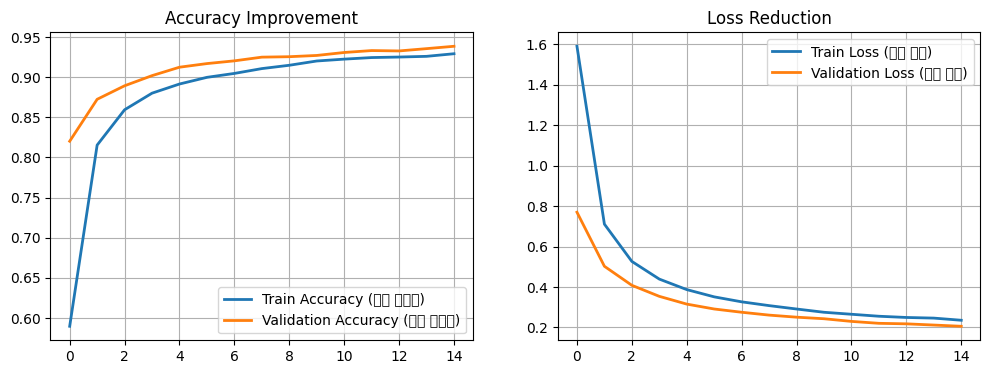

In [6]:
print("📈 [Part 5] 학습 진행 상황을 그래프로 확인합니다...")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))

# 정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy (학습 정확도)', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy (검증 정확도)', linewidth=2)
plt.legend(loc='lower right')
plt.title('Accuracy Improvement')
plt.grid(True)

# 오차(Loss) 그래프
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss (학습 오차)', linewidth=2)
plt.plot(val_loss, label='Validation Loss (검증 오차)', linewidth=2)
plt.legend(loc='upper right')
plt.title('Loss Reduction')
plt.grid(True)

plt.show()

무작위 이미지 예측 테스트

🎯 [Part 6] 실전 테스트! AI가 무작위 잎사귀 사진을 진단합니다...


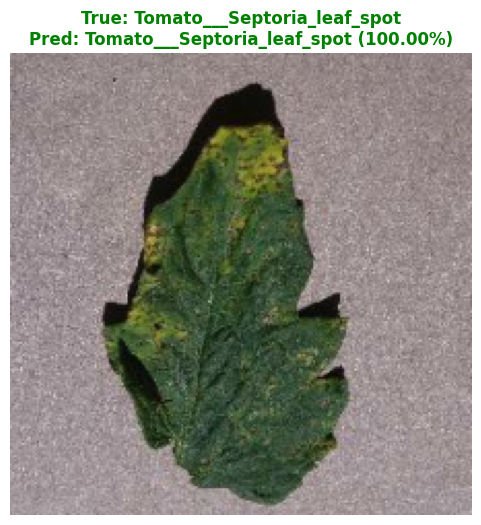

--------------------------------------------------
🌿 사진 속 실제 식물/질병: [Tomato___Septoria_leaf_spot]
🤖 AI 의사 진단 결과     : 100.00% 의 확신으로 [Tomato___Septoria_leaf_spot] 진단!
🎉 완벽합니다! AI가 정확하게 진단했습니다.


In [7]:
print("🎯 [Part 6] 실전 테스트! AI가 무작위 잎사귀 사진을 진단합니다...")

# 1. 검증 데이터셋을 마구 섞고 1묶음을 가져옴
for images, labels in validation_dataset.shuffle(100).take(1):
    # 그 안에서 랜덤 번호를 하나 뽑아 진짜 무작위 사진 1장을 선택
    random_index = random.randint(0, len(images) - 1)

    image = images[random_index]
    true_label = labels[random_index].numpy()
    break

# 2. 모델 예측
img_array = tf.expand_dims(image, 0)
predictions = model.predict(img_array, verbose=0) # 로그 숨김

# 모델이 내뱉은 완벽한 확률 정보 바로 사용
score = predictions[0]

# 3. 결과 해석
predicted_class_index = np.argmax(score)
predicted_class_name = class_names[predicted_class_index]
true_class_name = class_names[true_label]

confidence = 100 * np.max(score)

# 4. 결과 시각화
plt.figure(figsize=(6, 6))
plt.imshow(image.numpy().astype("uint8"))

text_color = 'green' if true_class_name == predicted_class_name else 'red'
plt.title(f"True: {true_class_name}\nPred: {predicted_class_name} ({confidence:.2f}%)",
          color=text_color, fontsize=12, fontweight='bold')
plt.axis('off')
plt.show()

print("-" * 50)
print(f"🌿 사진 속 실제 식물/질병: [{true_class_name}]")
print(f"🤖 AI 의사 진단 결과     : {confidence:.2f}% 의 확신으로 [{predicted_class_name}] 진단!")
if true_class_name == predicted_class_name:
    print("🎉 완벽합니다! AI가 정확하게 진단했습니다.")
else:
    print("🥲 아쉽네요. 다음 사진에서 다시 실력을 발휘해 볼까요?")